# Proyecto Final 4Geeks - FAOSTAT

Proyecto ejecutado de punta a punta con datos publicos de FAOSTAT. Este notebook documenta la definicion del problema, la obtencion de datos, el almacenamiento en SQLite, el analisis descriptivo/EDA, el entrenamiento del modelo y la app de despliegue.

## Paso 1: Definición del problema

**Problema de negocio:** estimar el valor esperado de bioenergía por país, año, item y tipo de medición para apoyar decisiones de inversion e investigación agroalimentaria.

La fuente solicitada fue `https://www.fao.org/faostat/en/#data/AF`. En el catálogo oficial de FAOSTAT, `AF` corresponde a **ASTI - Researchers**. Como este dominio es pequeno para el requisito de 60.000 filas, se usa como fuente contextual y se combina con otros dominios FAOSTAT relacionados:

- `AF`: investigadores ASTI, fuente solicitada.
- `AE`: gasto en investigación agricola.
- `CISP`: inversión y valor agregado agropecuario.
- `BE`: bioenergía, tabla principal del modelo.

**Variable objetivo:** `target_value`, valor histórico de producción o consumo de bioenergía. Para el modelo se usa `log_target_value = log1p(target_value)` para reducir el peso de valores extremos.

In [1]:
import json
import sqlite3
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from config import DATABASE_PATH, METADATA_PATH, MODELING_DATA_PATH, MODEL_PATH
from data_download import DATASETS, download_all, load_raw_frames
from database import run_example_queries, store_database
from eda import run_eda
from features import build_modeling_dataset
from train_model import train

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.3f}".format)
ROOT

PosixPath('/Users/dragcessa/Desktop/Proyecto Final 4geeks')

## Paso 2: Obtención y carga del conjunto de datos

Los datos se obtienen desde descargas bulk oficiales de FAOSTAT. El pipeline guarda los ZIP originales en `data/raw/` y luego los carga con Pandas.

In [2]:
download_all(skip_if_present=True)
frames = load_raw_frames()

source_summary = pd.DataFrame([
    {
        "codigo": code,
        "nombre": DATASETS[code]["name"],
        "rol": DATASETS[code]["role"],
        "filas": frame.shape[0],
        "columnas": frame.shape[1],
    }
    for code, frame in frames.items()
])
source_summary

,codigo,nombre,rol,filas,columnas
0,AF,ASTI - Researchers,requested_source,3800,20
1,AE,ASTI - Expenditures,context,7789,17
2,BE,Bioenergy,model_base,122374,14
3,CISP,Country Investment Statistics Profile,context,66447,15


## Paso 3: Almacenar la información en SQLite

Se crea una base SQLite con las tablas crudas y una tabla final de modelado. También se ejecutan consultas SQL con `SELECT`, `JOIN`, agregaciones e `INSERT` para demostrar almacenamiento y explotación de la base.

In [3]:
modeling = build_modeling_dataset(frames)
db_path = store_database(frames, modeling)

print(f"Base SQLite creada en: {db_path}")
print(f"Dataset final: {modeling.shape[0]:,} filas x {modeling.shape[1]:,} columnas")
modeling.head()

Base SQLite creada en: /Users/dragcessa/Desktop/Proyecto Final 4geeks/data/database/faostat_project.db
Dataset final: 101,995 filas x 29 columnas


,area_key,area,item,element,unit,year,target_value,item_code,element_code,flag,af_value,ae_value,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_agriculture_orientation_index_us,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_share_of_total_us,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_agriculture_orientatio,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_total_us_2015,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_share_of_total_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices,target_lag_1,target_lag_2,target_lag_3,target_roll_mean_3,year_since_1990,log_target_value,has_asti_context
0,'001,World,Animal waste,Energy consumption,TJ,1990,"125,022.962",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,11.736,0
1,'001,World,Animal waste,Energy consumption,TJ,1991,"124,374.750",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"125,022.962",NaN,NaN,"125,022.962",1,11.731,0
2,'001,World,Animal waste,Energy consumption,TJ,1992,"129,583.912",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"124,374.750","125,022.962",NaN,"124,698.856",2,11.772,0
3,'001,World,Animal waste,Energy consumption,TJ,1993,"132,484.296",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"129,583.912","124,374.750","125,022.962","126,327.208",3,11.794,0
4,'001,World,Animal waste,Energy consumption,TJ,1994,"220,653.224",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"132,484.296","129,583.912","124,374.750","128,814.319",4,12.304,0


In [4]:
with sqlite3.connect(DATABASE_PATH) as conn:
    tables = pd.read_sql_query("""
        SELECT name AS tabla
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
    """, conn)

tables

,tabla
0,modeling_bioenergy
1,project_notes
2,raw_ae
3,raw_af
4,raw_be
5,raw_cisp
6,sqlite_sequence


In [5]:
queries = run_example_queries()
queries["select_top_bioenergy"]

,area,item,element,year,unit,target_value
0,World,Total Bioenergy,Energy production,2023,TJ,"49,649,777.821"
1,World,Total Bioenergy,Energy production,2022,TJ,"49,249,521.252"
2,World,Total Bioenergy,Energy production,2021,TJ,"48,834,808.458"
3,World,Total Bioenergy,Energy production,2019,TJ,"47,600,276.009"
4,World,Total Bioenergy,Energy production,2020,TJ,"47,277,121.662"
5,World,Total Bioenergy,Energy production,2018,TJ,"47,236,838.919"
6,World,Total Bioenergy,Energy production,2017,TJ,"46,202,523.428"
7,World,Total Bioenergy,Energy production,2016,TJ,"45,502,367.582"
8,World,Total Bioenergy,Energy production,2015,TJ,"44,515,778.663"
9,World,Total Bioenergy,Energy production,2014,TJ,"44,069,611.062"


In [6]:
queries["join_be_af"].head(10)

,area,year,item,element,target_value,asti_research_context
0,Afghanistan,1990,Charcoal,Energy consumption,"1,150.323",None
1,Afghanistan,1990,Charcoal,Energy production,"1,150.323",None
2,Afghanistan,1990,Fuelwood,Energy consumption,"4,176.997",None
3,Afghanistan,1990,Fuelwood,Energy production,"6,314.258",None
4,Afghanistan,1990,Solid biofuels,Energy consumption,"5,327.320",None
5,Afghanistan,1990,Solid biofuels,Energy production,"6,314.258",None
6,Afghanistan,1990,Total Bioenergy,Energy consumption,"5,327.320",None
7,Afghanistan,1990,Total Bioenergy,Energy production,"6,314.258",None
8,Afghanistan,1991,Charcoal,Energy consumption,"1,190.236",None
9,Afghanistan,1991,Charcoal,Energy production,"1,190.236",None


## Paso 4: Análisis descriptivo

Se revisan dimensiones, tipos de variables, nulos y medidas estadísticas de la variable objetivo. El dataset supera el minimo solicitado: más de 60.000 filas y más de 20 predictores, con variables categóricas.

In [7]:
summary = run_eda(modeling)
summary

{'rows': 101995,
 'columns': 29,
 'numeric_predictors': 19,
 'categorical_predictors': 8,
 'target_mean': 447212.7152551684,
 'target_median': 11815.2,
 'target_std': 2193562.0872654812,
 'missing_rate': 0.192605114179025}

In [8]:
predictor_count = len([c for c in modeling.columns if c not in ["target_value", "log_target_value", "flag", "flag_description"]])
categorical_predictors = modeling.select_dtypes(include="object").columns.tolist()

pd.DataFrame({
    "indicador": ["filas", "columnas", "predictores", "variables_categoricas"],
    "valor": [modeling.shape[0], modeling.shape[1], predictor_count, len(categorical_predictors)]
})

,indicador,valor
0,filas,101995
1,columnas,29
2,predictores,26
3,variables_categoricas,8


In [9]:
modeling[["target_value", "log_target_value", "year", "target_lag_1", "target_roll_mean_3"]].describe().T

,count,mean,std,min,25%,50%,75%,max
target_value,"101,995.000","447,212.715","2,193,562.087",0.000,788.523,"11,815.200","106,215.000","49,649,777.821"
log_target_value,"101,995.000",9.020,3.547,0.000,6.671,9.377,11.573,17.721
year,"101,995.000","2,007.752",9.645,"1,990.000","2,000.000","2,008.000","2,016.000","2,023.000"
target_lag_1,"98,277.000","446,417.216","2,184,391.461",0.000,800.988,"11,918.000","106,755.262","49,249,521.252"
target_roll_mean_3,"98,277.000","439,032.608","2,154,299.470",0.000,786.318,"11,582.667","103,696.667","48,453,817.124"


In [10]:
modeling.select_dtypes(include="object").nunique().sort_values(ascending=False).to_frame("valores_unicos")

,valores_unicos
area_key,270
area,270
item,15
item_code,15
flag,3
element,2
element_code,2
unit,1


### Distribución de predictores y contraste de hipotesis

Para cubrir el análisis descriptivo de las predictoras, se calcula una lectura automática de distribución para cada variable numérica: media, mediana, desviación, sesgo, curtosis y una interpretación simple. También se realiza un contraste de hipótesis para validar si existen diferencias estadísticamente significativas en el valor de bioenergía entre tipos de `item`.

- **H0:** la distribución del valor objetivo es similar entre grupos de `item`.
- **H1:** al menos un grupo de `item` presenta diferencias relevantes.
- Se usa Kruskal-Wallis porque el objetivo es muy asimétrico y no conviene asumir normalidad.

In [11]:
numeric_predictors = [
    col for col in modeling.select_dtypes(include="number").columns
    if col not in ["target_value", "log_target_value"]
]

distribution_rows = []
for col in numeric_predictors:
    series = pd.to_numeric(modeling[col], errors="coerce").dropna()
    if series.empty:
        continue
    skewness = series.skew()
    if abs(skewness) < 0.5:
        interpretation = "aprox. simetrica"
    elif skewness > 0:
        interpretation = "asimetrica positiva"
    else:
        interpretation = "asimetrica negativa"
    distribution_rows.append({
        "predictora": col,
        "n": len(series),
        "media": series.mean(),
        "mediana": series.median(),
        "desv_std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "sesgo": skewness,
        "curtosis": series.kurtosis(),
        "lectura_distribucion": interpretation,
    })

distribution_table = pd.DataFrame(distribution_rows).sort_values("predictora")
distribution_table

,predictora,n,media,mediana,desv_std,min,max,sesgo,curtosis,lectura_distribucion
2,ae_value,28533,"27,076.050","1,635.402","137,078.344",0.180,"1,313,874.331",7.325,57.174,asimetrica positiva
1,af_value,28786,"7,818.422","1,215.450","19,509.377",4.000,"158,196.050",4.947,27.790,asimetrica positiva
3,cisp_dfa_disbursement_to_agriculture_forestry_...,47145,0.598,0.340,1.428,0.000,44.896,13.963,301.855,asimetrica positiva
4,cisp_dfa_disbursement_to_agriculture_forestry_...,47605,5.175,4.292,5.083,0.000,82.928,5.179,48.335,asimetrica positiva
5,cisp_dfa_disbursement_to_agriculture_forestry_...,47605,525.683,52.168,"1,585.265",0.000,"18,221.096",5.873,43.949,asimetrica positiva
6,cisp_gross_fixed_capital_formation_agriculture...,67757,0.859,0.547,0.868,0.011,13.022,4.740,44.021,asimetrica positiva
7,cisp_gross_fixed_capital_formation_agriculture...,67757,4.846,3.504,4.765,0.030,89.327,4.491,44.274,asimetrica positiva
8,cisp_gross_fixed_capital_formation_agriculture...,67757,18.511,12.808,17.827,0.152,247.041,3.978,31.720,asimetrica positiva
9,cisp_gross_fixed_capital_formation_agriculture...,67757,"16,473.740","1,198.637","56,402.832",0.027,"683,856.096",6.810,54.963,asimetrica positiva
10,cisp_value_added_agriculture_forestry_and_fish...,69818,2.287,2.571,8.899,-71.865,123.420,1.178,17.569,asimetrica positiva


In [12]:
from scipy.stats import kruskal

sample_for_test = modeling[["item", "target_value"]].dropna()
item_groups = [
    group["target_value"].sample(min(len(group), 3000), random_state=42)
    for _, group in sample_for_test.groupby("item")
    if len(group) >= 30
]

statistic, p_value = kruskal(*item_groups)
alpha = 0.05
pd.DataFrame({
    "contraste": ["Kruskal-Wallis por item"],
    "estadistico": [statistic],
    "p_value": [p_value],
    "alpha": [alpha],
    "decision": ["rechazar H0" if p_value < alpha else "no rechazar H0"],
    "interpretacion": [
        "El valor de bioenergia cambia significativamente segun el item."
        if p_value < alpha
        else "No hay evidencia suficiente de diferencias por item."
    ],
})

,contraste,estadistico,p_value,alpha,decision,interpretacion
0,Kruskal-Wallis por item,"4,860.412",0.000,0.050,rechazar H0,El valor de bioenergia cambia significativamen...


## Paso 5: EDA completo

Los gráficos principales se guardan en `reports/figures/` y quedan renderizados aqui para revisar tendencias, items dominantes y valores nulos.

bioenergy_trend.png


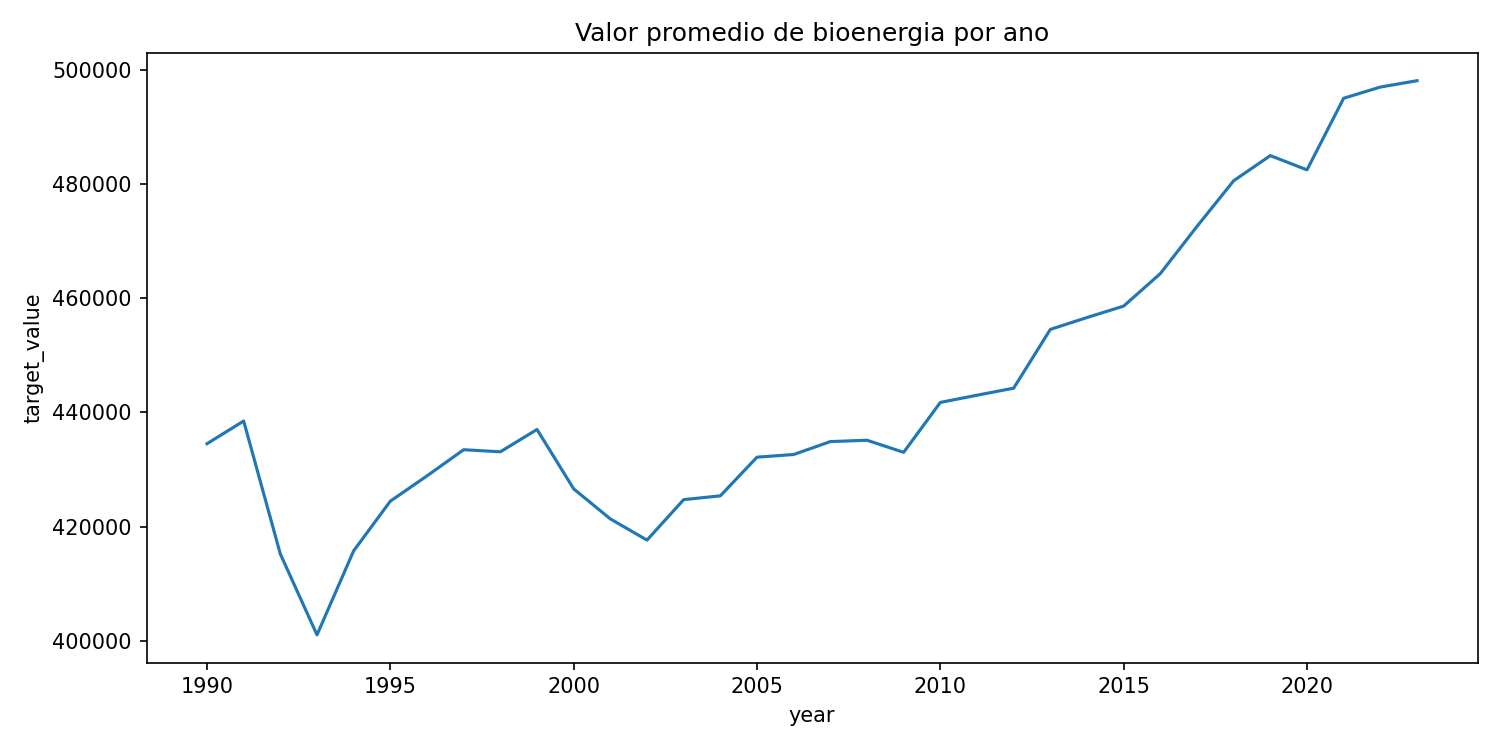

top_items.png


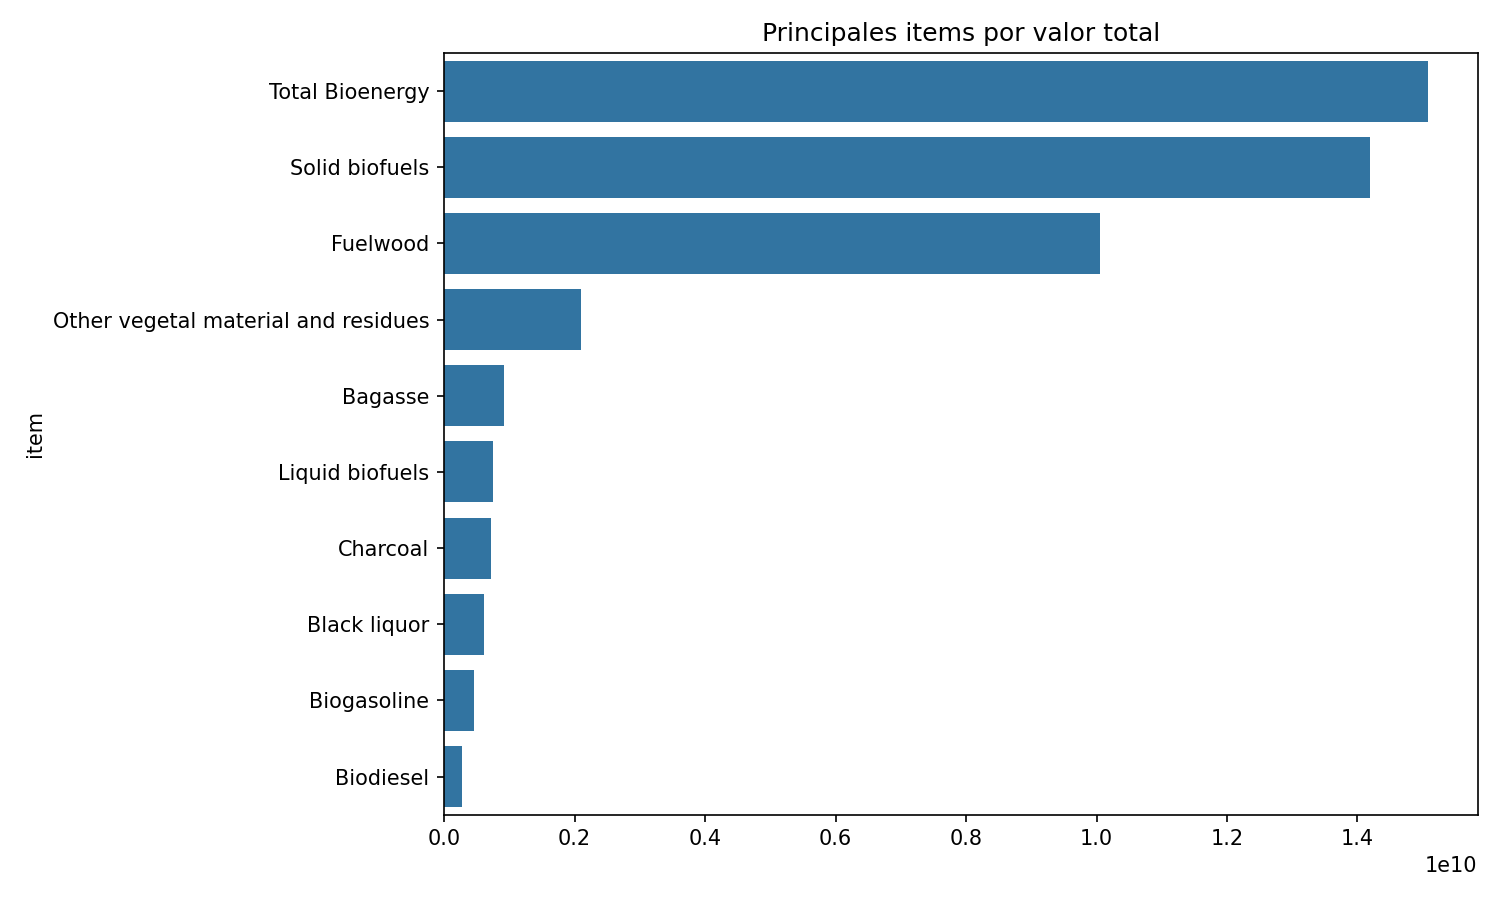

missing_values.png


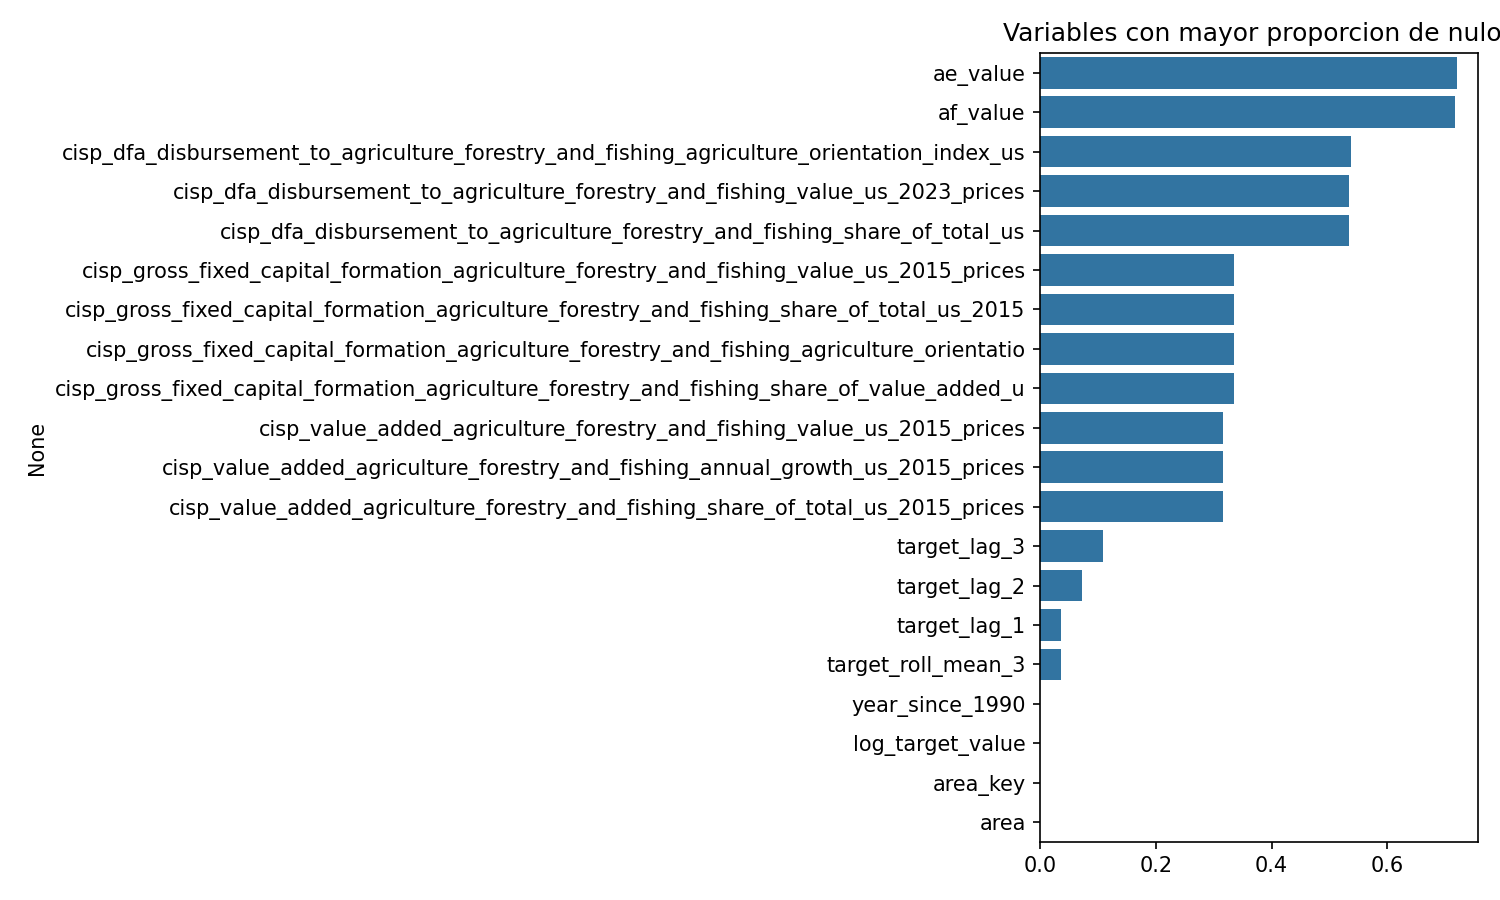

In [13]:
for figure in ["bioenergy_trend.png", "top_items.png", "missing_values.png"]:
    print(figure)
    display(Image(filename=str(ROOT / "reports" / "figures" / figure)))

In [14]:
top_area_item = (
    modeling.groupby(["area", "item"], as_index=False)["target_value"]
    .sum()
    .sort_values("target_value", ascending=False)
    .head(15)
)
top_area_item

,area,item,target_value
1945,World,Total Bioenergy,"2,382,037,027.720"
1944,World,Solid biofuels,"2,231,720,645.990"
1261,Non-Annex I countries,Total Bioenergy,"1,883,970,761.401"
1260,Non-Annex I countries,Solid biofuels,"1,824,577,416.221"
1939,World,Fuelwood,"1,557,433,296.900"
1255,Non-Annex I countries,Fuelwood,"1,276,283,152.578"
108,Asia,Total Bioenergy,"1,063,803,980.112"
107,Asia,Solid biofuels,"1,040,611,178.156"
1030,Low Income Food Deficit Countries (LIFDCs),Total Bioenergy,"927,977,914.856"
1029,Low Income Food Deficit Countries (LIFDCs),Solid biofuels,"926,355,850.672"


### División train/test

Para respetar la naturaleza temporal del problema, el entrenamiento usa anos antiguos y el test usa años más recientes cuando hay suficientes años disponibles.

In [15]:
cutoff = int(modeling["year"].quantile(0.80))
train_rows = int((modeling["year"] <= cutoff).sum())
test_rows = int((modeling["year"] > cutoff).sum())

pd.DataFrame({
    "particion": ["train", "test"],
    "criterio": [f"year <= {cutoff}", f"year > {cutoff}"],
    "filas": [train_rows, test_rows]
})

,particion,criterio,filas
0,train,year <= 2018,84749
1,test,year > 2018,17246


## Paso 6: Construcción y optimización del modelo

Se entrena un `HistGradientBoostingRegressor`, un modelo robusto para relaciones no lineales y variables mixtas. La optimizacion se realiza con `GridSearchCV`. Las metricas se guardan en `models/model_metadata.json` y el modelo en `models/bioenergy_model.joblib`.

In [16]:
metrics = train(modeling)
metrics

{'rows_total': 101995,
 'rows_train': 84749,
 'rows_test': 17246,
 'predictor_count': 26,
 'categorical_predictor_count': 7,
 'numeric_predictor_count': 19,
 'rmse': 641472.2323296726,
 'mae': 60528.01643029755,
 'r2_log_target': 0.9904561092501942,
 'best_params': {'model__learning_rate': 0.08,
  'model__max_iter': 140,
  'model__max_leaf_nodes': 31}}

In [17]:
metadata = json.loads(METADATA_PATH.read_text())
pd.DataFrame([
    {"metrica": "MAE", "valor": metadata["metrics"]["mae"]},
    {"metrica": "RMSE", "valor": metadata["metrics"]["rmse"]},
    {"metrica": "R2 log-target", "valor": metadata["metrics"]["r2_log_target"]},
    {"metrica": "Predictores", "valor": metadata["metrics"]["predictor_count"]},
    {"metrica": "Train rows", "valor": metadata["metrics"]["rows_train"]},
    {"metrica": "Test rows", "valor": metadata["metrics"]["rows_test"]},
])

,metrica,valor
0,MAE,"60,528.016"
1,RMSE,"641,472.232"
2,R2 log-target,0.990
3,Predictores,26.000
4,Train rows,"84,749.000"
5,Test rows,"17,246.000"


In [18]:
model = joblib.load(MODEL_PATH)
example = modeling[metadata["features"]].sample(5, random_state=42)
predictions = model.predict(example)

preview = example[["area", "year", "item", "element", "unit"]].copy()
preview["prediccion_valor"] = np.expm1(predictions)
preview

,area,year,item,element,unit,prediccion_valor
85984,Small Island Developing States (SIDS),1998,Fuelwood,Energy consumption,TJ,"143,416.811"
9138,Caribbean,2000,Charcoal,Energy consumption,TJ,"29,570.528"
74178,Pakistan,2002,Animal waste,Energy production,TJ,"14,561.087"
62727,Lithuania,2020,Biodiesel,Energy production,TJ,"6,133.023"
73264,Norway,2022,Biogasoline,Energy consumption,TJ,"2,893.831"


## Paso 7: Despliegue del modelo

La aplicacion web esta en `src/app.py`. Se puede ejecutar localmente con:

```bash
streamlit run src/app.py
```

Para Render, el proyecto incluye `render.yaml`, que instala dependencias, ejecuta el pipeline si hace falta y levanta Streamlit.

In [19]:
print("App local: streamlit run src/app.py")
print("Archivo Render: render.yaml")
print("Modelo guardado:", MODEL_PATH.exists(), MODEL_PATH)
print("Metadata guardada:", METADATA_PATH.exists(), METADATA_PATH)

App local: streamlit run src/app.py
Archivo Render: render.yaml
Modelo guardado: True /Users/dragcessa/Desktop/Proyecto Final 4geeks/models/bioenergy_model.joblib
Metadata guardada: True /Users/dragcessa/Desktop/Proyecto Final 4geeks/models/model_metadata.json


## Conclusiones para la presentacion

- El proyecto convierte una necesidad de negocio en un problema de regresion supervisada.
- La obtencion de datos es reproducible desde FAOSTAT y queda almacenada en CSV/SQLite.
- El dataset final cumple el volumen esperado para la entrega: 101.995 filas y 26 predictores.
- Las variables temporales (`lags` y media movil) son claves para explicar el comportamiento de bioenergia.
- La app permite simular escenarios por pais, ano, item y elemento.